In [ ]:
import os, sys, json, time, math, socket, subprocess, platform, threading, queue, datetime
from pathlib import Path
from scapy.all import sniff

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7,4)

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces


In [ ]:
DATA_PATH = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"  # <- your uploaded file

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df.head()

Raw shape: (225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Standardize column names (strip spaces etc.)
df.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in df.columns]

# Identify the label column (common names: 'Label')
label_col_candidates = [c for c in df.columns if c.lower() == "label"]
assert len(label_col_candidates) == 1, f"Expected a 'Label' column, found {label_col_candidates}"
LABEL_COL = label_col_candidates[0]

# Binary map: benign -> 0 , anything else -> 1
df[LABEL_COL] = (df[LABEL_COL].astype(str).str.lower() != "benign").astype(int)

# Keep numeric columns + label
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if LABEL_COL in num_cols:
    pass
else:
    num_cols.append(LABEL_COL)

df = df[num_cols].copy()

# Clean NaN/Inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("After cleaning:", df.shape)
print("Attack ratio:", df[LABEL_COL].mean().round(4))


After cleaning: (225711, 79)
Attack ratio: 0.5672


In [ ]:
print("Shape:", df.shape)
dups = df.duplicated().sum()
print("Duplicates:", dups)
if dups > 0:
    df = df.drop_duplicates()
    print("After dropping dups:", df.shape)


Shape: (225711, 79)
Duplicates: 2629
After dropping dups: (223082, 79)


In [ ]:
print(df.describe().T.head(10))


                                count          mean           std  min  \
Destination_Port             223082.0  8.979381e+03  1.984477e+04  0.0   
Flow_Duration                223082.0  1.643543e+07  3.166173e+07 -1.0   
Total_Fwd_Packets            223082.0  4.905806e+00  1.551075e+01  1.0   
Total_Backward_Packets       223082.0  4.612134e+00  2.188157e+01  0.0   
Total_Length_of_Fwd_Packets  223082.0  9.497895e+02  3.267283e+03  0.0   
Total_Length_of_Bwd_Packets  223082.0  6.030165e+03  3.944650e+04  0.0   
Fwd_Packet_Length_Max        223082.0  5.446480e+02  1.874374e+03  0.0   
Fwd_Packet_Length_Min        223082.0  2.790494e+01  1.642536e+02  0.0   
Fwd_Packet_Length_Mean       223082.0  1.664811e+02  5.076555e+02  0.0   
Fwd_Packet_Length_Std        223082.0  2.174683e+02  8.018097e+02  0.0   

                                 25%           50%           75%           max  
Destination_Port                80.0  8.000000e+01  8.000000e+01  6.553200e+04  
Flow_Duration          

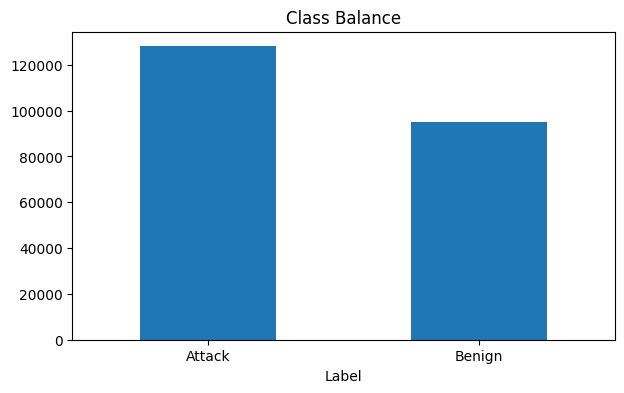

In [ ]:
# Class balance
counts = df[LABEL_COL].value_counts().rename({0:"Benign",1:"Attack"})
ax = counts.plot(kind="bar", rot=0, title="Class Balance")
plt.show()


In [ ]:
# Simple correlation with label (top 15)
corr = df.corr(numeric_only=True)[LABEL_COL].sort_values(ascending=False)
corr.head(15)


Label                     1.000000
Bwd_Packet_Length_Mean    0.599916
Avg_Bwd_Segment_Size      0.599916
Bwd_Packet_Length_Max     0.573809
Bwd_Packet_Length_Std     0.572738
Packet_Length_Mean        0.448248
Average_Packet_Size       0.447548
Packet_Length_Std         0.437650
Max_Packet_Length         0.408031
Packet_Length_Variance    0.403164
PSH_Flag_Count            0.240429
Flow_IAT_Std              0.123267
Flow_IAT_Mean             0.120763
Fwd_IAT_Max               0.099966
Flow_IAT_Max              0.094693
Name: Label, dtype: float64

In [ ]:
top_feats = corr.abs().sort_values(ascending=False).head(11).index.tolist()  # include label
sns.pairplot(df[top_feats].sample(min(3000, len(df))), hue=LABEL_COL, diag_kind="hist")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Features + target
X = df.drop(columns=[LABEL_COL])
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

pipe = Pipeline([
    ("scaler", scaler),
    ("rf", rf)
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("Baseline Accuracy:", round(accuracy_score(y_test, pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nClassification report:\n", classification_report(y_test, pred))

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cbar=False, cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Save trained model
joblib.dump(pipe, "model.pkl")
print("✅ Trained model saved as model.pkl")




In [ ]:
class AIDRSEnv(gym.Env):
    metadata = {'render.modes': ['human']}
    def __init__(self, X_np, y_np):
        super().__init__()
        self.X = X_np
        self.y = y_np
        self.n_features = X_np.shape[1]
        self.action_space = spaces.Discrete(2)   # 0 allow, 1 block
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_features,), dtype=np.float32)
        self.index = 0
        self.order = np.arange(len(self.X))
        np.random.shuffle(self.order)

        # reward shaping
        self.r_true_pos = 1.0   # block attack (correct)
        self.r_true_neg = 0.5   # allow benign (correct)
        self.r_false_pos = -0.7 # block benign
        self.r_false_neg = -1.0 # allow attack

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.index = 0
        np.random.shuffle(self.order)
        obs = self.X[self.order[self.index]].astype(np.float32)
        return obs, {}

    def step(self, action):
        i = self.order[self.index]
        label = int(self.y[i]) # 1=attack, 0=benign

        # reward
        if action == 1 and label == 1:   # blocked attack (TP)
            reward = self.r_true_pos
        elif action == 0 and label == 0: # allowed benign (TN)
            reward = self.r_true_neg
        elif action == 1 and label == 0: # blocked benign (FP)
            reward = self.r_false_pos
        else:                            # allowed attack (FN)
            reward = self.r_false_neg

        self.index += 1
        terminated = self.index >= len(self.X)
        truncated = False

        obs = self.X[self.order[self.index-1]].astype(np.float32) if not terminated else np.zeros(self.n_features, dtype=np.float32)
        info = {"label": label}
        return obs, reward, terminated, truncated, info

    def render(self):
        pass


In [ ]:
# Fit scaler on train only (already in baseline pipe). Use same scaler.
scaler = pipe.named_steps["scaler"]
X_train_scaled = scaler.transform(X_train).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)


In [ ]:
from collections import deque, namedtuple
import random

Transition = namedtuple('Transition', ('state','action','reward','next_state','done'))

class QNet(nn.Module):
    def __init__(self, n_features, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_actions)
        )
    def forward(self, x):
        return self.net(x)

class DQNAgent:
    def __init__(self, n_features, n_actions=2, lr=1e-3, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.995, buffer_size=100_000, batch_size=256, target_sync=200):
        self.n_actions = n_actions
        self.q = QNet(n_features, n_actions)
        self.target = QNet(n_features, n_actions)
        self.target.load_state_dict(self.q.state_dict())
        self.optim = optim.Adam(self.q.parameters(), lr=lr)
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.step_count = 0
        self.target_sync = target_sync
        self.loss_fn = nn.SmoothL1Loss()

    def act(self, state):
        if random.random() < self.eps:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            qvals = self.q(torch.from_numpy(state).float().unsqueeze(0))
            return int(torch.argmax(qvals, dim=1).item())

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return None
        batch = random.sample(self.buffer, self.batch_size)
        batch = Transition(*zip(*batch))

        state      = torch.tensor(np.stack(batch.state), dtype=torch.float32)
        action     = torch.tensor(batch.action, dtype=torch.int64).unsqueeze(1)
        reward     = torch.tensor(batch.reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(np.stack(batch.next_state), dtype=torch.float32)
        done       = torch.tensor(batch.done, dtype=torch.float32).unsqueeze(1)

        # Q(s,a)
        qsa = self.q(state).gather(1, action)

        # Target: r + gamma * max_a' Q_target(s',a') * (1 - done)
        with torch.no_grad():
            max_next = self.target(next_state).max(1, keepdim=True)[0]
            target_q = reward + (1 - done) * self.gamma * max_next

        loss = self.loss_fn(qsa, target_q)
        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 1.0)
        self.optim.step()

        self.step_count += 1
        if self.step_count % self.target_sync == 0:
            self.target.load_state_dict(self.q.state_dict())

        # epsilon decay
        if self.eps > self.eps_end:
            self.eps *= self.eps_decay

        return float(loss.item())


In [ ]:
env = AIDRSEnv(X_train_scaled, y_train)
test_env = AIDRSEnv(X_test_scaled, y_test)
agent = DQNAgent(n_features=X_train_scaled.shape[1])

episodes = 10   # increase for better learning (e.g., 50–200)
rewards_hist, losses = [], []

for ep in range(1, episodes+1):
    state, _ = env.reset()
    ep_reward, steps = 0.0, 0
    while True:
        action = agent.act(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        agent.push(state, action, reward, next_state, float(done))
        state = next_state
        ep_reward += reward
        steps += 1

        loss = agent.train_step()

        if done:
            break
    rewards_hist.append(ep_reward)
    if loss is not None: losses.append(loss)
    print(f"Episode {ep}/{episodes} | reward={ep_reward:.1f} | eps={agent.eps:.3f}")

plt.plot(rewards_hist); plt.title("DQN: Episode reward"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.show()


In [ ]:
def dqn_predict(agent, X_scaled):
    preds = []
    with torch.no_grad():
        for i in range(len(X_scaled)):
            qvals = agent.q(torch.from_numpy(X_scaled[i]).float().unsqueeze(0))
            action = int(torch.argmax(qvals, dim=1).item())  # 0 allow -> benign; 1 block -> attack
            preds.append(action)
    return np.array(preds)

dqn_preds = dqn_predict(agent, X_test_scaled)


accuracy = accuracy_score(y_test, dqn_preds)
print("DQN Accuracy:", round(accuracy, 4)) 
print(classification_report(y_test, dqn_preds))
sns.heatmap(confusion_matrix(y_test, dqn_preds), annot=True, fmt="d", cbar=False, cmap="Purples")
plt.title("DQN Confusion Matrix")
plt.xlabel("Predicted (0=allow/benign, 1=block/attack)"); plt.ylabel("True"); plt.show()

In [ ]:
from scapy.all import sniff, IP, TCP, UDP

LIVE_LOG = "live_events.csv"
BLOCK_THRESHOLD = 5      # number of attack decisions in window to block
WINDOW_SECONDS = 30
ip_scores = {}

# Minimal feature extractor consistent with numeric input (map missing to 0)
# You may want to align these with training features for best accuracy.
feat_names = X.columns.tolist()
n_features = len(feat_names)

def packet_to_feature_vector(pkt, last_seen_cache={}):
    # Very basic illustrative features; customize to match your training data schema if possible
    now = time.time()
    length = len(pkt.original) if hasattr(pkt, "original") else (int(pkt.len) if hasattr(pkt, "len") else 0)
    proto_tcp = int(TCP in pkt)
    proto_udp = int(UDP in pkt)
    src = pkt[IP].src if IP in pkt else "0.0.0.0"
    dst = pkt[IP].dst if IP in pkt else "0.0.0.0"
    flow_key = (src, dst, proto_tcp, proto_udp)

    last_t = last_seen_cache.get(flow_key, now)
    iat = now - last_t
    last_seen_cache[flow_key] = now

    # Build vector with zeros, set only a few features we have; rest zero
    v = np.zeros(n_features, dtype=np.float32)
    # Try to map common CICIDS names if they exist; otherwise fall back to first positions
    name_map = {
        'Flow_Duration': iat*1e6,   # micros
        'TotLen_Fwd_Pkts': length,
        'Protocol': 6 if proto_tcp else (17 if proto_udp else 0),
        'Fwd_Packets/s': 1.0/max(iat,1e-6),
        'Bwd_Packets/s': 0.0,
        'Flow_IAT_Mean': iat,
    }
    for k, val in name_map.items():
        if k in feat_names:
            idx = feat_names.index(k)
            v[idx] = val
    # if none matched, stuff basic features into first slots
    if not any(k in feat_names for k in name_map.keys()):
        v[:5] = [length, proto_tcp, proto_udp, iat, 1.0/max(iat,1e-6)]
    return v

def decide_and_log(pkt):
    try:
        if IP not in pkt:
            return
        src_ip = pkt[IP].src

        v = packet_to_feature_vector(pkt)
        v_scaled = scaler.transform(v.reshape(1,-1)).astype(np.float32)
        with torch.no_grad():
            qvals = agent.q(torch.from_numpy(v_scaled.squeeze()).float().unsqueeze(0))
            action = int(torch.argmax(qvals, dim=1).item())  # 1 means "block"
        verdict = "BLOCK" if action == 1 else "ALLOW"

        # update sliding window score
        now = time.time()
        ip_scores.setdefault(src_ip, deque())
        ip_scores[src_ip].append(now)
        # purge old
        while ip_scores[src_ip] and now - ip_scores[src_ip][0] > WINDOW_SECONDS:
            ip_scores[src_ip].popleft()

        score = len(ip_scores[src_ip])

        # Log event
        row = {
            "ts": datetime.datetime.utcnow().isoformat()+"Z",
            "src_ip": src_ip,
            "dst_ip": pkt[IP].dst,
            "len": len(pkt),
            "proto": "TCP" if TCP in pkt else ("UDP" if UDP in pkt else "OTHER"),
            "verdict": verdict,
            "score_in_window": score
        }
        hdr = not Path(LIVE_LOG).exists()
        pd.DataFrame([row]).to_csv(LIVE_LOG, mode="a", index=False, header=hdr)

        # Auto-block if threshold exceeded and model says block
        if verdict == "BLOCK" and score >= BLOCK_THRESHOLD:
            block_ip(src_ip)

    except Exception as e:
        print("RT error:", e)

def start_sniff(interface=None, count=0):
    print("Starting live sniff (Ctrl-C to stop)...")
    sniff(prn=decide_and_log, store=False, count=count, iface=interface, filter="ip")


In [ ]:
def run_cmd(cmd):
    print(">", " ".join(cmd))
    try:
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
        return out.decode()
    except subprocess.CalledProcessError as e:
        return e.output.decode()

def block_ip(ip):
    system = platform.system().lower()
    print(f"[ACTION] Blocking {ip}")
    if "windows" in system:
        return run_cmd(["netsh", "advfirewall", "firewall", "add", "rule", f"name=Block_{ip}", "dir=in", "action=block", f"remoteip={ip}"])
    else:
        # Linux/mac: prefer iptables (Linux) or pf (macOS). Below: iptables example.
        return run_cmd(["sudo", "iptables", "-A", "INPUT", "-s", ip, "-j", "DROP"])

def unblock_ip(ip):
    system = platform.system().lower()
    print(f"[ACTION] Unblocking {ip}")
    if "windows" in system:
        return run_cmd(["netsh", "advfirewall", "firewall", "delete", "rule", f"name=Block_{ip}"])
    else:
        return run_cmd(["sudo", "iptables", "-D", "INPUT", "-s", ip, "-j", "DROP"])


In [ ]:
BLOCKLIST_FILE = "blocklist.json"
def load_blocklist():
    if Path(BLOCKLIST_FILE).exists():
        return set(json.load(open(BLOCKLIST_FILE)))
    return set()

def save_blocklist(s):
    json.dump(sorted(list(s)), open(BLOCKLIST_FILE, "w"), indent=2)

blocklist = load_blocklist()

def policy_evaluate_from_log(threshold=10, window_sec=60):
    if not Path(LIVE_LOG).exists():
        print("No live log yet.")
        return
    df_live = pd.read_csv(LIVE_LOG)
    now = pd.to_datetime(datetime.datetime.utcnow(), utc=True)
    df_live["ts"] = pd.to_datetime(df_live["ts"], utc=True, errors="coerce")
    recent = df_live[df_live["ts"] > (now - pd.Timedelta(seconds=window_sec))]
    if recent.empty:
        print("No recent events.")
        return
    suspicious = (recent["verdict"]=="BLOCK").groupby(recent["src_ip"]).sum()
    for ip, cnt in suspicious.items():
        if cnt >= threshold and ip not in blocklist:
            print(f"[POLICY] Auto-blocking {ip} (cnt={cnt})")
            block_ip(ip)
            blocklist.add(ip)
    save_blocklist(blocklist)

# Example (run periodically):
# policy_evaluate_from_log(threshold=5, window_sec=30)


In [ ]:
def simulate_events_from_test(n=1000, delay=0.05):
    import random
    Path(LIVE_LOG).unlink(missing_ok=True)
    for i in range(min(n, len(X_test_scaled))):
        v = X_test_scaled[i]
        with torch.no_grad():
            qvals = agent.q(torch.from_numpy(v).float().unsqueeze(0))
            action = int(torch.argmax(qvals, dim=1).item())
        verdict = "BLOCK" if action==1 else "ALLOW"
        # fake IPs: benign=10.x, attack=192.168.x for visualization
        src_ip = f"10.0.0.{random.randint(1,254)}" if y_test[i]==0 else f"192.168.0.{random.randint(1,254)}"
        row = {
            "ts": datetime.datetime.utcnow().isoformat()+"Z",
            "src_ip": src_ip,
            "dst_ip": f"172.16.0.{random.randint(1,254)}",
            "len": int(np.clip(np.random.normal(500,120), 60, 1500)),
            "proto": "TCP",
            "verdict": verdict,
            "score_in_window": 1
        }
        hdr = not Path(LIVE_LOG).exists()
        pd.DataFrame([row]).to_csv(LIVE_LOG, mode="a", index=False, header=hdr)
        time.sleep(delay)

# simulate_events_from_test(n=500, delay=0.02)


In [ ]:
MODEL_FILE = "dqn_ids.py"
torch.save({"state_dict": agent.q.state_dict(),
            "n_features": X_train_scaled.shape[1]}, MODEL_FILE)
print("Saved:", MODEL_FILE)

# To load later:
# ckpt = torch.load(MODEL_FILE, map_location="cpu")
# agent = DQNAgent(n_features=ckpt["n_features"])
# agent.q.load_state_dict(ckpt["state_dict"])
# agent.target.load_state_dict(agent.q.state_dict())


In [ ]:
from scapy.all import sniff
import csv

# your interface
iface = "\\Device\\NPF_{BEA6856A-382B-4785-ADF1-B55C393E5FAA}"

# logging function
def log_packet(pkt):
    with open("live_events.csv", "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            pkt.time,
            pkt[0][1].src if hasattr(pkt[0][1], "src") else "N/A",
            pkt[0][1].dst if hasattr(pkt[0][1], "dst") else "N/A",
            pkt[0][1].name if hasattr(pkt[0][1], "name") else "N/A",
            len(pkt),
            pkt.summary(),
            "benign"  # placeholder verdict
        ])

# start sniffing (limit 50 packets)
sniff(iface=iface, filter="ip", prn=log_packet, store=False, count=50)


In [ ]:
from scapy.all import get_if_list, get_if_addr

for iface in get_if_list():
    try:
        print(iface, "->", get_if_addr(iface))
    except:
        pass

\Device\NPF_{D4412552-1F68-45E9-92D9-1731B13A9245} -> 0.0.0.0
\Device\NPF_{BEA6856A-382B-4785-ADF1-B55C393E5FAA} -> 0.0.0.0
\Device\NPF_{25DF768F-903D-4614-8461-AFF2BE1B9504} -> 0.0.0.0
\Device\NPF_{8DDB2273-9A87-46F9-BE95-481A9EF3CA21} -> 192.168.1.12
\Device\NPF_{4E89D1B4-1A5A-4BA8-A8C7-2C9F5212A927} -> 169.254.245.61
\Device\NPF_{C5CB2D2B-1CA3-493A-B5A7-86785FE6E27B} -> 169.254.192.221
\Device\NPF_Loopback -> 127.0.0.1
\Device\NPF_{13411DFA-505E-4F87-B94C-1A763B5048B6} -> 169.254.106.236
